# Project 2 - Horse Colic

## Research question
What are the main indicators of colic severity in horses, and is it possible to track them with wearables?

Colic is a common but incredibly dangerous medical condition for horses. It presents suddenly, requires immediate treatment, and is the leading cause of death in horses. The Horse Colic dataset from UCI Machine Learning Repository contains data on many different biometrics, many of which could be tracked with wearables. I want to use a decision tree to explore which factors play the biggest role in the severity of the condition, meaning which ones lead to fatalities. If several key metrics are trackable with wearable devices, then it could lead to owners being notified of a potential problem and horses getting early treatment.

After learning more about real time monitoring and wearables in the guest lecture today, I brought up the possibility of extending it to equestrian athletes and veterinary science with my group. Animals struggle to communicate their discomfort, so real time data analysis could make a huge difference in animal healthcare. We discussed possible applications of real time monitoring, and decided the horses in the equestrian industry seemed like a good place to start due to the well established history and economic significance. A lot of biological data is collected on horses, so datasets are available to train a machine learning model. The equestrian industry has a clear economic incentive to maintain the health of these high value horses and invest in improvements to healthcare technology. Most importantly, developing a method of predicting colic could save countless horses' lives.

In [177]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

### Loading the Datasets

The data is split up into three files, horse-colic.data, horse-colic.test, and horse-colic.names. The data is already separated into a train and test split, so that step is already complete and won't be needed later. The .data and .test files don't have the column headers, which are detailed in .names, so those will be added in manually.

In [178]:
df = pd.read_csv(
    "datasets/horse-colic.data",
    delim_whitespace=True,   # space separated
    header=None,             # no column names in file
    na_values="?"            # treat ? as NaN
)

df.head()

C:\Users\KayleePatersonBICTUS\AppData\Local\Temp\ipykernel_34252\3889995910.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2


In [179]:
columns = [
    "surgery", "age", "hospital_number", "rectal_temp", "pulse",
    "respiratory_rate", "temp_extremities", "peripheral_pulse",
    "mucous_membranes", "capillary_refill_time", "pain",
    "peristalsis", "abdominal_distension", "nasogastric_tube",
    "nasogastric_reflux", "nasogastric_reflux_ph", "rectal_exam_feces",
    "abdomen", "packed_cell_volume", "total_protein",
    "abdominocentesis_appearance", "abdom_protein", "outcome",
    "surgical_lesion", "type_of_lesion_1", "type_of_lesion_2",
    "type_of_lesion_3", "cp_data"
]

df.columns = columns

In [180]:
df.head()

,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdom_protein,outcome,surgical_lesion,type_of_lesion_1,type_of_lesion_2,type_of_lesion_3,cp_data
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2


In [181]:
df_test = pd.read_csv(
    "datasets/horse-colic.test",
    delim_whitespace=True,
    header=None,
    na_values="?"
)

df_test.columns = columns

df.head()

C:\Users\KayleePatersonBICTUS\AppData\Local\Temp\ipykernel_34252\735637688.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_test = pd.read_csv(


,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdom_protein,outcome,surgical_lesion,type_of_lesion_1,type_of_lesion_2,type_of_lesion_3,cp_data
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2


### Dataset Overview

This dataset comes from the UCI Machine Learning Repository and contains clinical data on horses diagnosed with colic. It includes 368 total instances, split into 300 training examples and 68 test examples, with 28 attributes per case.

The features include a mix of:
- Continuous variables (e.g., pulse, temperature)
- Categorical variables (e.g., pain level, abdominal distension)
- Clinical observations (e.g., mucous membranes, peristalsis)

The target variable is **outcome**, which represents:
- 1 = lived  
- 2 = died  
- 3 = euthanized  

## Data Preprocessing & Assumptions

In [182]:
df.isna().sum()

surgery                          1
age                              0
hospital_number                  0
rectal_temp                     60
pulse                           24
respiratory_rate                58
temp_extremities                56
peripheral_pulse                69
mucous_membranes                47
capillary_refill_time           32
pain                            55
peristalsis                     44
abdominal_distension            56
nasogastric_tube               104
nasogastric_reflux             106
nasogastric_reflux_ph          247
rectal_exam_feces              102
abdomen                        118
packed_cell_volume              29
total_protein                   33
abdominocentesis_appearance    165
abdom_protein                  198
outcome                          1
surgical_lesion                  0
type_of_lesion_1                 0
type_of_lesion_2                 0
type_of_lesion_3                 0
cp_data                          0
dtype: int64

In [183]:
df.dtypes

surgery                        float64
age                              int64
hospital_number                  int64
rectal_temp                    float64
pulse                          float64
respiratory_rate               float64
temp_extremities               float64
peripheral_pulse               float64
mucous_membranes               float64
capillary_refill_time          float64
pain                           float64
peristalsis                    float64
abdominal_distension           float64
nasogastric_tube               float64
nasogastric_reflux             float64
nasogastric_reflux_ph          float64
rectal_exam_feces              float64
abdomen                        float64
packed_cell_volume             float64
total_protein                  float64
abdominocentesis_appearance    float64
abdom_protein                  float64
outcome                        float64
surgical_lesion                  int64
type_of_lesion_1                 int64
type_of_lesion_2         

In [184]:
df_test.isna().sum()

surgery                         1
age                             0
hospital_number                 0
rectal_temp                     9
pulse                           2
respiratory_rate               13
temp_extremities                9
peripheral_pulse               14
mucous_membranes                1
capillary_refill_time           6
pain                            8
peristalsis                     8
abdominal_distension            9
nasogastric_tube               27
nasogastric_reflux             27
nasogastric_reflux_ph          52
rectal_exam_feces              26
abdomen                        25
packed_cell_volume              8
total_protein                  10
abdominocentesis_appearance    29
abdom_protein                  37
outcome                         1
surgical_lesion                 0
type_of_lesion_1                0
type_of_lesion_2                0
type_of_lesion_3                0
cp_data                         0
dtype: int64

In [185]:
df_test.dtypes

surgery                        float64
age                              int64
hospital_number                  int64
rectal_temp                    float64
pulse                          float64
respiratory_rate               float64
temp_extremities               float64
peripheral_pulse               float64
mucous_membranes               float64
capillary_refill_time          float64
pain                           float64
peristalsis                    float64
abdominal_distension           float64
nasogastric_tube               float64
nasogastric_reflux             float64
nasogastric_reflux_ph          float64
rectal_exam_feces              float64
abdomen                        float64
packed_cell_volume             float64
total_protein                  float64
abdominocentesis_appearance    float64
abdom_protein                  float64
outcome                        float64
surgical_lesion                  int64
type_of_lesion_1                 int64
type_of_lesion_2         

In [186]:
# Keeps only rows where column 'outcome' is NOT NaN
df = df[df['outcome'].notna()]
# Keeps only rows where column 'outcome' is NOT NaN
df_test = df_test[df_test['outcome'].notna()]


This dataset contains a significant amount of missing data (~30%). Dropping missing values would result in a significant amount of data lost, so missing values were instead filled using the median. Median imputation was chosen because it is robust to outliers and it preserves the distribution of numeric features.

Additionally, only features that could realistically be collected via wearable devices were selected. This required making assumptions about the capabilities of wearable technology.

Later on, the target variable was transformed from a 3 class problem into a binary classification problem by combining died and euthanized. This simplifies the model and aligns with the goal of identifying severe cases rather than distinguishing between death and euthanasia.

In [187]:
wearable_cols = [
    "rectal_temp",          # thermal sensors. could be replaced with skin temp sensors
    "pulse",                # heart rate sensors on neck or chest
    "respiratory_rate",     # can be estimated via sensors
    "temp_extremities",     # thermal sensors on limbs
    "peripheral_pulse",     # heart rate sensors on limbs
    "peristalsis",          # gut sounds via acoustic sensors
    "abdominal_distension"  # potentially gathered via girth sensors/pressure
]

In [188]:
# Features and target
X_train = df[wearable_cols]
y_train = df["outcome"]

X_test = df_test[wearable_cols]
y_test = df_test["outcome"]

In [189]:
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

## The Models

Since this is a classification problem, I started with a Decision Tree model. It has good interpretability, and is a good starting point for this project goal.

### Decision Tree Model

In [190]:
model = DecisionTreeClassifier(
    max_depth=4,
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [191]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7313432835820896
              precision    recall  f1-score   support

         1.0       0.85      0.85      0.85        47
         2.0       0.44      0.67      0.53        12
         3.0       0.50      0.12      0.20         8

    accuracy                           0.73        67
   macro avg       0.60      0.55      0.53        67
weighted avg       0.74      0.73      0.72        67



In [192]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=wearable_cols
).sort_values(ascending=False)

feature_importance

pulse                   0.422291
rectal_temp             0.287308
temp_extremities        0.153817
abdominal_distension    0.060258
peripheral_pulse        0.038178
peristalsis             0.038147
respiratory_rate        0.000000
dtype: float64

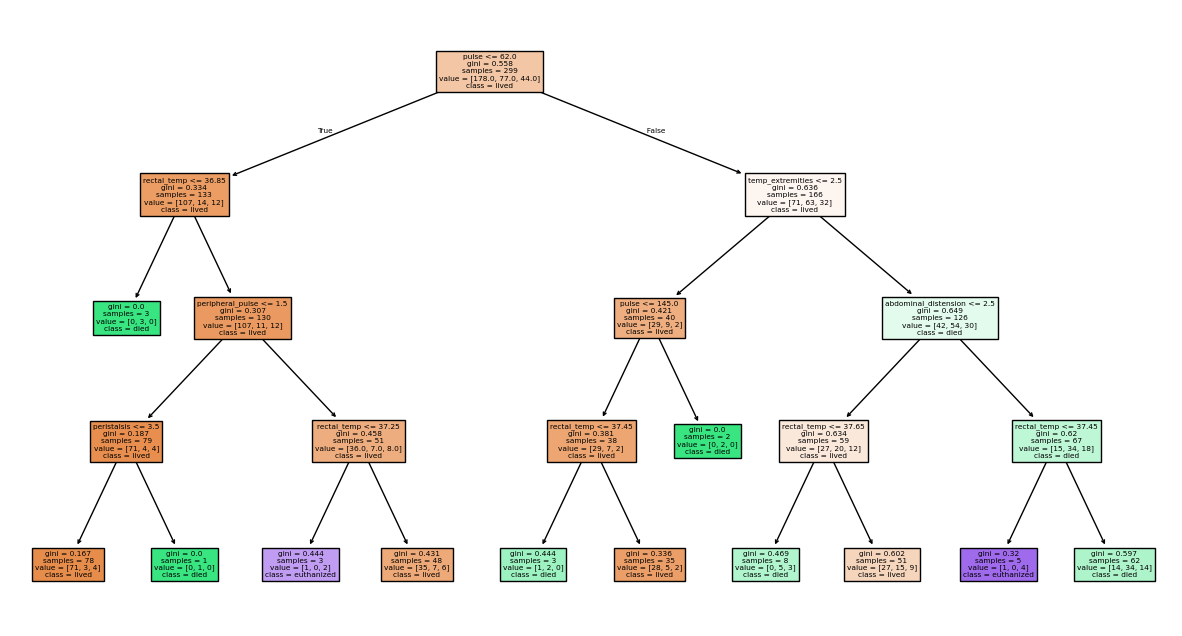

In [193]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plot_tree(
    model,
    feature_names=wearable_cols,
    class_names=["lived", "died", "euthanized"],
    filled=True
)
plt.show()

The macro recall isnt great, 55%. Recall is the priority here, I don't want any horses to fall through the cracks and miss a severe case. I'm going to try combining died and euthanized into one category for bad outcome, since the differentiation doesn't matter if I am simply trying to calculate severity.

In [194]:
y_test.value_counts()

outcome
1.0    47
2.0    12
3.0     8
Name: count, dtype: int64

In [195]:
y_train.value_counts()

outcome
1.0    178
2.0     77
3.0     44
Name: count, dtype: int64

In [196]:
y_train = y_train.replace({1: "lived", 2: "died", 3: "died"})
y_test = y_test.replace({1: "lived", 2: "died", 3: "died"})
print(y_train.value_counts())
print(y_test.value_counts())

outcome
lived    178
died     121
Name: count, dtype: int64
outcome
lived    47
died     20
Name: count, dtype: int64


In [197]:
# retrain model
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7611940298507462
              precision    recall  f1-score   support

        died       0.60      0.60      0.60        20
       lived       0.83      0.83      0.83        47

    accuracy                           0.76        67
   macro avg       0.71      0.71      0.71        67
weighted avg       0.76      0.76      0.76        67



This is already a major improvement in overall recall score. I'm going to try a few things to help improve it even further.

## Tuned Decision Tree Model

In [198]:
model = DecisionTreeClassifier(
    max_depth=4,
    class_weight={"lived": 1, "died": 2}  # increase weight on "died"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7611940298507462
              precision    recall  f1-score   support

        died       0.58      0.70      0.64        20
       lived       0.86      0.79      0.82        47

    accuracy                           0.76        67
   macro avg       0.72      0.74      0.73        67
weighted avg       0.78      0.76      0.77        67



The recall on Died went up, but there is room for improvement. I'm going to try increasing model complexity.

In [199]:
model = DecisionTreeClassifier(
    max_depth=6,              # increase depth
    min_samples_leaf=5,       # avoid overfitting
    class_weight={"lived": 1, "died": 2}
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5522388059701493
              precision    recall  f1-score   support

        died       0.34      0.55      0.42        20
       lived       0.74      0.55      0.63        47

    accuracy                           0.55        67
   macro avg       0.54      0.55      0.53        67
weighted avg       0.62      0.55      0.57        67



### Random Forest Model

The decision tree still isn't performing well. The random forest model might help. The random forest model might help reduce overfitting and provide more generalized predictions for complicated patterns. It is more robust against unreliable data, which is very valuable for this dataset.

In [200]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight={"lived": 1, "died": 2},
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.746268656716418
              precision    recall  f1-score   support

        died       0.55      0.80      0.65        20
       lived       0.89      0.72      0.80        47

    accuracy                           0.75        67
   macro avg       0.72      0.76      0.73        67
weighted avg       0.79      0.75      0.76        67



### Tuned Random Forest Model

The random forest is performing much better. The interpretability is lower, but I believe that is a fine trade in this use case. I'm going to try some hyperparameter tuning to make the model even more accurate.

In [201]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=500,          # increase number of trees
    max_depth=10,          
    min_samples_leaf=3,        
    class_weight={"lived": 1, "died": 2}, 
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight={'died': 2, 'lived': 1}, max_depth=10,
                       min_samples_leaf=3, n_estimators=500)

In [202]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7611940298507462
              precision    recall  f1-score   support

        died       0.57      0.80      0.67        20
       lived       0.90      0.74      0.81        47

    accuracy                           0.76        67
   macro avg       0.73      0.77      0.74        67
weighted avg       0.80      0.76      0.77        67



I adjusted the class weights to improve recall again, which was very helpful in improving the random forest. The overall complexity was also increased with more trees and more depth. These changes improved the model's ability to identify high risk outcomes, which can make a massive difference in early intervention and treatment. 

### Visualizations

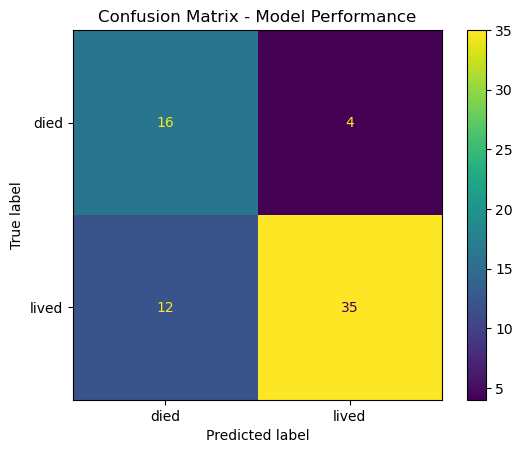

In [203]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
)

plt.title("Confusion Matrix - Model Performance")
plt.show()

This is a count of how many cases were in each category. As seen in the chart, the testing dataset is quite small, which is a key limitation of this dataset. 

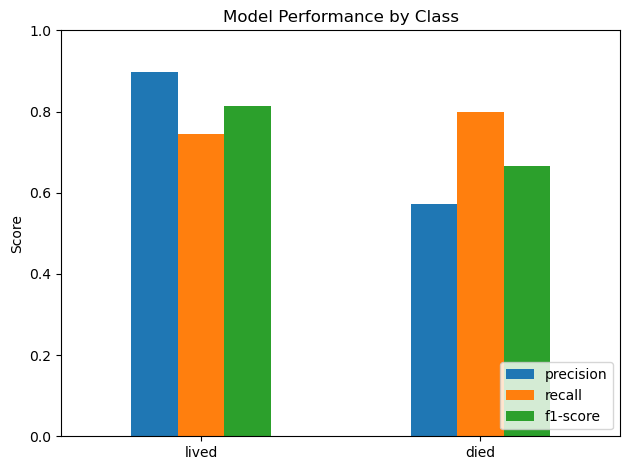

In [204]:
# Get classification report
report = classification_report(y_test, y_pred, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Keep only actual classes (remove avg rows)
report_df = report_df.loc[["lived", "died"]]

# Plot
report_df[["precision", "recall", "f1-score"]].plot(kind="bar")

plt.title("Model Performance by Class")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

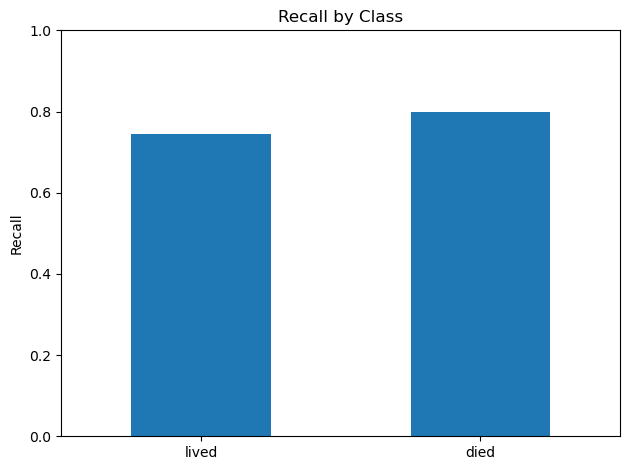

In [205]:
report_df["recall"].plot(kind="bar")

plt.title("Recall by Class")
plt.ylabel("Recall")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

This is a visualization of the scores for both classes. The first bar chart shows all of the metrics and compares them to each other, and the second one focuses is on the most important metric, which is recall.

In [206]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=wearable_cols
).sort_values(ascending=False)

print(feature_importance)

pulse                   0.289127
rectal_temp             0.141540
respiratory_rate        0.137923
peripheral_pulse        0.129569
temp_extremities        0.116285
abdominal_distension    0.109693
peristalsis             0.075863
dtype: float64


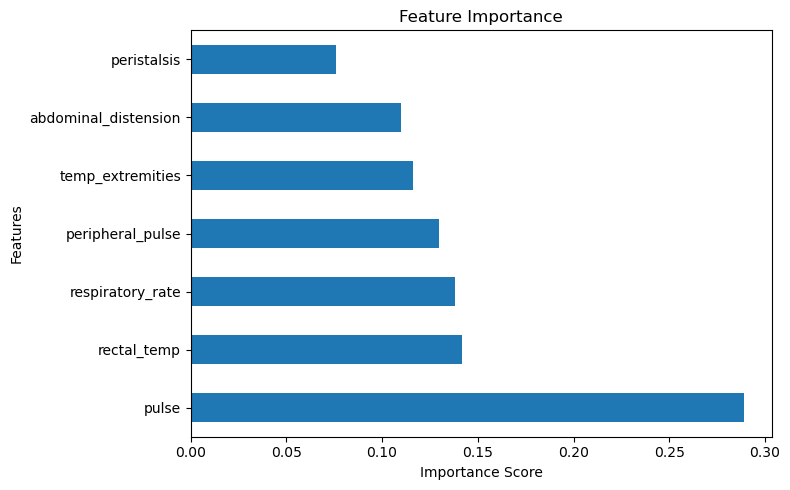

In [208]:
plt.figure(figsize=(8, 5))
feature_importance.plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

This shows how important each feature is in the predictions, and how strongly correlated it is to the outcome.

### Model Evaluation & Interpretation

The final Random Forest model achieved significantly higher recall for the "died" class compared to the decision tree models. This is very important for this use case, as the goal is to minimize false negatives (cases where a severe condition is missed).

The improvement in recall can be attributed to a few things. The Random Forest model is simply better suited to this problem. As stated earlier, it handles the complexities of the dataset well. Also, class weighting made a huge difference in prioritising lethal cases.

The feature importance plot highlights which measurable variables contribute most to predicting severe outcomes. Pulse and abdominal distension rank highly, indicating a strong relationship with colic severity. This supports the hypothesis that wearable devices tracking cardiovascular activity and physical changes could be effective in early detection. However, none of the individual variables has a particularly strong correlation with severity, meaning that it is the combination of these metrics that allows the predictions to work.

This suggests that wearable monitoring of these metrics could provide meaningful early warning signals for severe colic cases, as well as other conditions.

### Limitations & Ethical Considerations

This analysis has several limitations:

- The dataset contains a high percentage of missing values, which may reduce model accuracy.
- Many features included in the wearable subset are not currently measurable with standard wearable devices and would require advancements in technology.
- The dataset is relatively small, which limits the available training data for the model.
- Clinical data contains subjectivity (e.g., pain levels), which wearables are unable to track.
- Each horse is different, and this model does not account for the normal conditions of each horse.

From an ethical perspective, false positives may lead to unnecessary concern or intervention, while false negatives could result in delayed treatment and harm to the animal. This model performed well, but not well enough. Several lethal cases of colic went unnoticed, which could lead to the horse going untreated.

If too much trust is placed in wearable devices false negatives are highly dangerous. Reliance on automated systems should not replace professional veterinary judgment but rather serve as a supplementary tool.

### References

- [UCI Machine Learning Repository: Horse Colic Dataset](https://archive.ics.uci.edu/dataset/47/horse+colic)
- [Scikit-learn documentation](https://scikit-learn.org/stable/)

### AI Transparency

ChatGPT was used to assist with debugging and explanation of machine learning concepts. All final decisions, analysis, and interpretations were completed by me.